In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [34]:
# Load the preprocessed feature set
df = pd.read_csv('../data/processed/cc_underwriting_preprocessed.csv')
print(f"Preprocessed shape: {df.shape}")

# Pull application_year from the raw data — needed for out-of-time splitting.
# It may have been dropped during IV filtering in notebook 02.
raw = pd.read_csv('../data/raw/cc_underwriting_100k.csv', usecols=['applicant_id', 'application_year'])

if 'application_year' not in df.columns:
    # Reattach year using the row index (both files share the same row order)
    df['application_year'] = raw['application_year'].values
    print("application_year reattached from raw data")
else:
    print("application_year already present in preprocessed data")

print(f"\nYear distribution:")
print(df['application_year'].value_counts().sort_index())

Preprocessed shape: (100000, 80)
application_year reattached from raw data

Year distribution:
application_year
2020    19797
2021    20375
2022    19917
2023    19880
2024    20031
Name: count, dtype: int64


## Split Strategy

### Why 60 / 20 / 20?
With 100,000 records a 60/20/20 split gives:
- **Train (60k):** Enough data to learn complex patterns and support cross-validation
- **Validation (20k):** Large enough for reliable hyperparameter tuning and early stopping
- **Test (20k):** Held-out set never seen during training or tuning — provides an unbiased final performance estimate

Smaller training fractions (e.g. 70/15/15) are common in smaller datasets. At 100k the 60/20/20 is more conservative but ensures the validation and test sets are statistically meaningful.

---

### Why Stratified Splitting?
The target `target_approved` is imbalanced (~65% Yes / ~35% No). Without stratification, random splits can produce sets with different class ratios by chance, which would make:
- Validation metrics inconsistent (the model appears better or worse than it is)
- Threshold tuning on validation data not transfer correctly to the test set

Stratified splitting forces each split to mirror the original 65/35 ratio exactly.

---

### Why Out-of-Time (OOT) Validation?
A random split mixes data from all years — the model sees future patterns during training, which inflates performance estimates. In production, a model trained today will score **future** applicants it has never seen.

Out-of-time splitting simulates this realistically:

| Split | Years | Approx Size | Purpose |
|---|---|---|---|
| **Train** | 2020 – 2022 | ~60k | Model learning |
| **Validation** | 2023 | ~20k | Hyperparameter tuning |
| **Test (OOT)** | 2024 | ~20k | Final unbiased evaluation |

A model that degrades significantly from validation → OOT test signals **concept drift** — the applicant population or economic conditions have shifted. This is critical for credit models which operate across multi-year cycles (expansions, rate hikes, recessions).


In [35]:
# ── Out-of-time split by application_year ────────────────────────────────────
train_mask = df['application_year'].isin([2020, 2021, 2022])
val_mask   = df['application_year'] == 2023
test_mask  = df['application_year'] == 2024

train_df = df[train_mask].copy()
val_df   = df[val_mask].copy()
test_df  = df[test_mask].copy()

total = len(df)
print("Out-of-time split results:")
print(f"  Train (2020–2022): {len(train_df):>6,}  ({len(train_df)/total*100:.1f}%)")
print(f"  Val   (2023):      {len(val_df):>6,}  ({len(val_df)/total*100:.1f}%)")
print(f"  Test  (2024):      {len(test_df):>6,}  ({len(test_df)/total*100:.1f}%)")

Out-of-time split results:
  Train (2020–2022): 60,089  (60.1%)
  Val   (2023):      19,880  (19.9%)
  Test  (2024):      20,031  (20.0%)


## Stratification Check

Because we split by year rather than randomly, we need to verify that the class ratio is consistent across all three splits. If one year had unusually high approval rates (e.g. due to a looser underwriting policy), the splits would have different base rates and comparisons would be misleading.

If the ratios diverge significantly we apply **stratified resampling within each year** to correct it.

In [36]:
# Check target distribution in each split
target_col = 'target_approved'

def approval_rate(subset):
    return (subset[target_col] == 'Yes').mean() * 100

overall_rate = approval_rate(df)
train_rate   = approval_rate(train_df)
val_rate     = approval_rate(val_df)
test_rate    = approval_rate(test_df)

print(f"{'Split':<10}  {'n':>6}  {'Approval %':>10}  {'Δ vs overall':>12}")
print("-" * 45)
print(f"{'Overall':<10}  {len(df):>6,}  {overall_rate:>10.2f}%")
print(f"{'Train':<10}  {len(train_df):>6,}  {train_rate:>10.2f}%  {train_rate - overall_rate:>+11.2f}%")
print(f"{'Val':<10}  {len(val_df):>6,}  {val_rate:>10.2f}%  {val_rate - overall_rate:>+11.2f}%")
print(f"{'Test':<10}  {len(test_df):>6,}  {test_rate:>10.2f}%  {test_rate - overall_rate:>+11.2f}%")

# Flag if any split deviates more than 3 percentage points from overall
threshold = 3.0
drifted = [(name, rate) for name, rate in [('Train', train_rate), ('Val', val_rate), ('Test', test_rate)]
           if abs(rate - overall_rate) > threshold]

if drifted:
    print(f"\n⚠  Splits with >3% deviation: {drifted}")
    print("   Applying stratified resampling to correct class ratios.")
else:
    print(f"\n✅ All splits within ±{threshold}% of overall approval rate — no resampling needed.")

Split            n  Approval %  Δ vs overall
---------------------------------------------
Overall     100,000       65.00%
Train       60,089       64.96%        -0.04%
Val         19,880       65.24%        +0.24%
Test        20,031       64.87%        -0.13%

✅ All splits within ±3.0% of overall approval rate — no resampling needed.


In [37]:
# Stratified resampling: if a split's approval rate drifts, downsample
# the majority class within that split to match the overall ratio.
# This preserves the OOT time structure while correcting for rate drift.

def stratify_to_target_rate(subset, target_rate, seed=42):
    """
    Downsample the majority class in subset so its approval rate
    matches target_rate. Returns resampled DataFrame.
    """
    approved     = subset[subset[target_col] == 'Yes']
    declined     = subset[subset[target_col] == 'No']
    n_declined   = len(declined)

    # Solve: n_approved / (n_approved + n_declined) = target_rate
    # => n_approved = target_rate * n_declined / (1 - target_rate)
    target_frac  = target_rate / 100
    n_approved_target = int(target_frac * n_declined / (1 - target_frac))

    if n_approved_target >= len(approved):
        # Need more approved than available — downsample declined instead
        n_declined_target = int(len(approved) * (1 - target_frac) / target_frac)
        declined = declined.sample(n=n_declined_target, random_state=seed)
    else:
        approved = approved.sample(n=n_approved_target, random_state=seed)

    return pd.concat([approved, declined]).sample(frac=1, random_state=seed).reset_index(drop=True)


# Only resample splits that deviate more than 3 percentage points
if abs(train_rate - overall_rate) > threshold:
    train_df = stratify_to_target_rate(train_df, overall_rate)
    print(f"Train resampled → {len(train_df):,} rows, approval rate: {approval_rate(train_df):.2f}%")

if abs(val_rate - overall_rate) > threshold:
    val_df = stratify_to_target_rate(val_df, overall_rate)
    print(f"Val resampled   → {len(val_df):,} rows, approval rate: {approval_rate(val_df):.2f}%")

if abs(test_rate - overall_rate) > threshold:
    test_df = stratify_to_target_rate(test_df, overall_rate)
    print(f"Test resampled  → {len(test_df):,} rows, approval rate: {approval_rate(test_df):.2f}%")

print("Stratification complete ✅")

Stratification complete ✅


## Split Visualisation

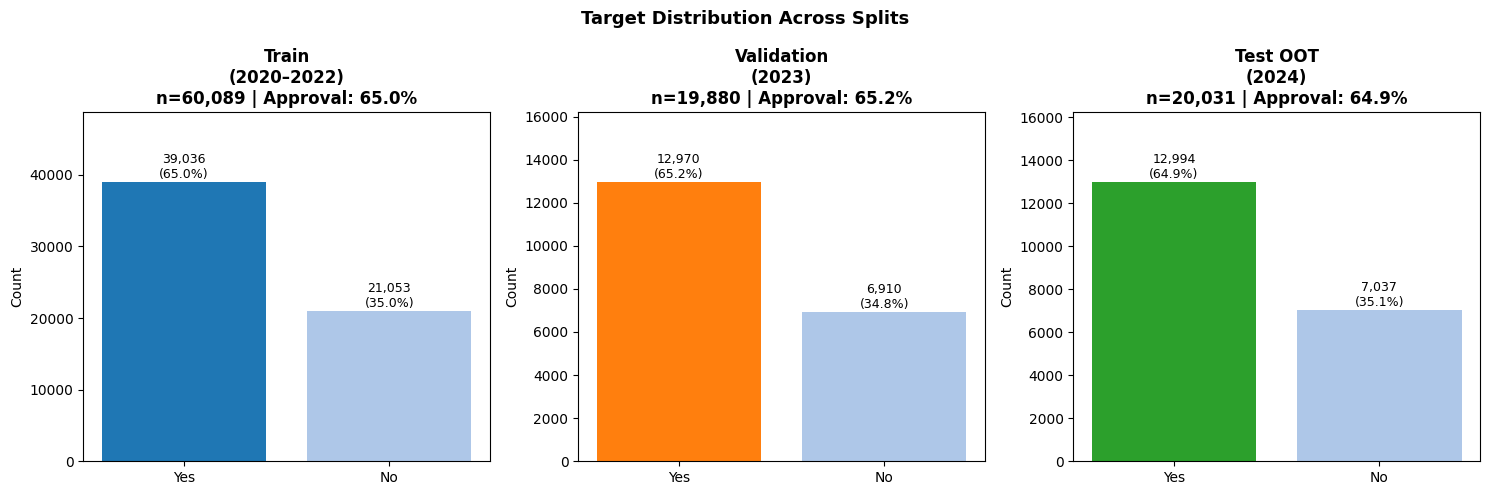

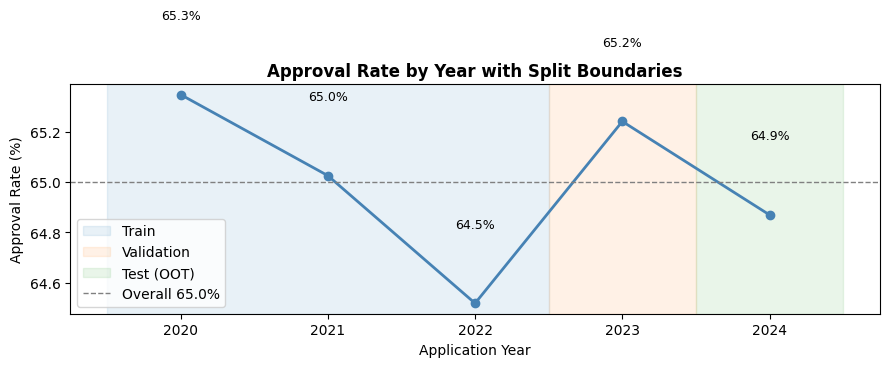

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

splits    = {'Train\n(2020–2022)': train_df, 'Validation\n(2023)': val_df, 'Test OOT\n(2024)': test_df}
colors    = ['#1f77b4', '#ff7f0e', '#2ca02c']

for ax, (label, subset), color in zip(axes, splits.items(), colors):
    counts = subset[target_col].value_counts()
    bars   = ax.bar(counts.index, counts.values, color=[color, '#aec7e8'])
    rate   = approval_rate(subset)

    # Annotate bars with count and percentage
    for bar, (cat, cnt) in zip(bars, counts.items()):
        pct = cnt / len(subset) * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                f'{cnt:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

    ax.set_title(f'{label}\nn={len(subset):,} | Approval: {rate:.1f}%', fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_ylim(0, max(counts.values) * 1.25)

fig.suptitle('Target Distribution Across Splits', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Year-over-year approval rate trend
yearly = df.groupby('application_year').apply(
    lambda x: pd.Series({'approval_rate': approval_rate(x), 'n': len(x)})
).reset_index()

fig2, ax = plt.subplots(figsize=(9, 4))
ax.plot(yearly['application_year'], yearly['approval_rate'], marker='o', linewidth=2, color='steelblue')

# Shade regions by split
ax.axvspan(2019.5, 2022.5, alpha=0.1, color='#1f77b4', label='Train')
ax.axvspan(2022.5, 2023.5, alpha=0.1, color='#ff7f0e', label='Validation')
ax.axvspan(2023.5, 2024.5, alpha=0.1, color='#2ca02c', label='Test (OOT)')

for _, row in yearly.iterrows():
    ax.text(row['application_year'], row['approval_rate'] + 0.3,
            f"{row['approval_rate']:.1f}%", ha='center', fontsize=9)

ax.axhline(overall_rate, linestyle='--', color='grey', linewidth=1, label=f'Overall {overall_rate:.1f}%')
ax.set_xlabel('Application Year')
ax.set_ylabel('Approval Rate (%)')
ax.set_title('Approval Rate by Year with Split Boundaries', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## Separate Features (X) and Target (y)

Drop `application_year` from the feature matrix — it was only needed to define the splits and must not be a model feature (it would cause data leakage by encoding the time period).

In [39]:
drop_from_features = ['target_approved', 'approved_binary', 'application_year']

def make_xy(subset):
    feature_cols = [c for c in subset.columns if c not in drop_from_features]
    X = subset[feature_cols]
    y = (subset['target_approved'] == 'Yes').astype(int)
    return X, y

X_train, y_train = make_xy(train_df)
X_val,   y_val   = make_xy(val_df)
X_test,  y_test  = make_xy(test_df)

print(f"X_train: {X_train.shape}  |  y_train approval rate: {y_train.mean()*100:.2f}%")
print(f"X_val:   {X_val.shape}  |  y_val   approval rate: {y_val.mean()*100:.2f}%")
print(f"X_test:  {X_test.shape}  |  y_test  approval rate: {y_test.mean()*100:.2f}%")
print(f"\nFeatures: {X_train.shape[1]}")

X_train: (60089, 78)  |  y_train approval rate: 64.96%
X_val:   (19880, 78)  |  y_val   approval rate: 65.24%
X_test:  (20031, 78)  |  y_test  approval rate: 64.87%

Features: 78


## Save Splits

In [40]:
# Save feature matrices and targets separately for clean loading in model notebooks
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_val.to_csv('../data/processed/X_val.csv',     index=False)
X_test.to_csv('../data/processed/X_test.csv',   index=False)

y_train.to_csv('../data/processed/y_train.csv', index=False, header=True)
y_val.to_csv('../data/processed/y_val.csv',     index=False, header=True)
y_test.to_csv('../data/processed/y_test.csv',   index=False, header=True)

print("Saved to data/processed/:")
print(f"  X_train.csv  {X_train.shape}")
print(f"  X_val.csv    {X_val.shape}")
print(f"  X_test.csv   {X_test.shape}")
print(f"  y_train.csv  {y_train.shape}")
print(f"  y_val.csv    {y_val.shape}")
print(f"  y_test.csv   {y_test.shape}")

Saved to data/processed/:
  X_train.csv  (60089, 78)
  X_val.csv    (19880, 78)
  X_test.csv   (20031, 78)
  y_train.csv  (60089,)
  y_val.csv    (19880,)
  y_test.csv   (20031,)
